# Feedback linearization of the control-affine ROM for the ball simulation

In this notebook, we control the movement of the ball using feedback linearization. Specifically, we exploit the control-affine structure of the ROM to find the input transformation that eliminates the nonlinearities of the latent dynamics.

In [1]:
import pickle
import torch
from matplotlib.font_manager import FontProperties

# Set Times font properties for publication-quality figures
times_font_path = '/usr/share/fonts/truetype/times.ttf'
try:
    times_font = FontProperties(fname=times_font_path)
    times_font_leg = FontProperties(fname=times_font_path)
except Exception as e:
    print(f"Warning: Font not found at {times_font_path} or could not be loaded. Using default font.")
    times_font = FontProperties()
    times_font_leg = FontProperties()
times_font.set_size(8)
times_font_leg.set_size(8)

# identify device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Load data
with open("./data/ball_in_box_data.pkl", "rb") as f:
    data = pickle.load(f)

# Extract data
frames, controls = data['Forced']
print("Frames shape:", frames.shape)
print("Controls shape:", controls.shape)

Using device: cuda
Frames shape: (10000, 64, 64)
Controls shape: (10000, 2)


### Data Preprocessing

Although the model has been trained, we load and process the data for obtaining the corresponding scaled initial conditions:

In [2]:
from deepe2erom import DataConfig, DataPreprocessor
import numpy as np

# Hyperparameters
lookback = 5
pred_horizon = 1

# Configure data preprocessor
config = DataConfig(
    # Data splitting
    train_split=0.5,
    val_split=0.1,
    test_split=0.4,
    
    # Sequence parameters
    lookback=lookback,             # Use 5 past time steps as input
    pred_horizon=pred_horizon,     # Predict 1 future time step
    stride=1,                      # No skipping between sequences
    
    # Scaling
    scale_states=True,
    scale_controls=False,
    scale_states_collectively=True,         # Scale all states together (one high-dimensional field)
    scale_controls_collectively=False,      # Scale controls separately
    scaling_method="minmax",                # Scaling method: "minmax" or "standard"
    
    # Device
    device=device
)

# Initialize data preprocessor
preprocessor = DataPreprocessor(config)

# reshape data for preprocessor (nb_simulations, time_steps, nb_channels, height, width)
reshaped_frames = frames[np.newaxis, :,np.newaxis,:,:]
print("Reshaped frames shape:", reshaped_frames.shape)
# reshape controls for preprocessor (nb_simulations, time_steps, nb_control_dims)
reshaped_controls = controls[np.newaxis, :, :]
print("Reshaped controls shape:", reshaped_controls.shape)

# Process data
processed_data = preprocessor.process_simulations(states=reshaped_frames, controls=reshaped_controls)

Reshaped frames shape: (1, 10000, 1, 64, 64)
Reshaped controls shape: (1, 10000, 2)
Single simulation detected. Splitting along time axis: Train=5000, Val=1000, Test=4000 steps.
Scaling states using:  minmax


/home/users/amj/anaconda3/envs/torchenv/lib/python3.11/site-packages/torch/cuda/__init__.py:497: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


### Create and load the trained model

In [3]:
from deepe2erom import create_model

# Hyperparameters
state_dim = reshaped_frames.shape[2:]  # (nb_channels, height, width)
latent_dim = 2
control_dim = reshaped_controls.shape[-1]

encoder_arch = [
    {"type": "Conv2d", "params": {"in_channels": 1, "out_channels": 4, "kernel_size": 3, "stride": 2, "padding": 1}},
    {"type": "ReLU"},
    {"type": "Conv2d", "params": {"in_channels": 4, "out_channels": 8, "kernel_size": 3, "stride": 2, "padding": 1}},
    {"type": "ReLU"},
    {"type": "Conv2d", "params": {"in_channels": 8, "out_channels": 16, "kernel_size": 3, "stride": 2, "padding": 1}},
    {"type": "ReLU"},
    {"type": "Conv2d", "params": {"in_channels": 16, "out_channels": 32, "kernel_size": 3, "stride": 2, "padding": 1}},
    {"type": "ReLU"},
    {"type": "Flatten"},
    {"type": "Linear", "params": {"in_features": 32 * 4 * 4, "out_features": 128}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 128, "out_features": latent_dim}},
    {"type": "Sigmoid"}
]

decoder_arch = [
    {"type": "Linear", "params": {"in_features": latent_dim, "out_features": 128}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 128, "out_features": 32 * 4 * 4}},
    {"type": "Unflatten", "params": {"dim": 1, "unflattened_size": (32, 4, 4)}},
    {"type": "ConvTranspose2d", "params": {"in_channels": 32, "out_channels": 16, "kernel_size": 3, "stride": 2, "padding": 1, "output_padding": 1}},
    {"type": "ReLU"},
    {"type": "ConvTranspose2d", "params": {"in_channels": 16, "out_channels": 8, "kernel_size": 3, "stride": 2, "padding": 1, "output_padding": 1}},
    {"type": "ReLU"},
    {"type": "ConvTranspose2d", "params": {"in_channels": 8, "out_channels": 4, "kernel_size": 3, "stride": 2, "padding": 1, "output_padding": 1}},
    {"type": "ReLU"},
    {"type": "ConvTranspose2d", "params": {"in_channels": 4, "out_channels": 1, "kernel_size": 3, "stride": 2, "padding": 1, "output_padding": 1}},
    {"type": "Sigmoid"}
]

dim_dynamics = latent_dim*lookback + control_dim*(lookback-1)
drift_arch = [
    {"type": "Linear", "params": {"in_features": dim_dynamics, "out_features": 256}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 256, "out_features": 256}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 256, "out_features": 256}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 256, "out_features": latent_dim}}, 
]

input_net = [
    {"type": "Linear", "params": {"in_features": dim_dynamics, "out_features": 256}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 256, "out_features": 256}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 256, "out_features": 256}},
    {"type": "ReLU"},
    {"type": "Linear", "params": {"in_features": 256, "out_features": latent_dim * control_dim}},
]

# Create model
model = create_model(
    state_dim=state_dim,
    control_dim=control_dim,
    lookback=lookback,
    pred_horizon=pred_horizon,
    latent_dim=latent_dim,
    dynamics_type="control_affine",
    encoder_arch=encoder_arch,
    decoder_arch=decoder_arch,
    drift_arch=drift_arch,
    input_arch=input_net,
    device=device,
    seed=42
)

# load the model
model.load_state_dict(torch.load('./results_control_affine/best_model.pth'))

<All keys matched successfully>

### Reference tracking using feedback linearization 

We first build a synthetic latent-space reference trajectory which consists of two steps corresponding to two randomly chosen ball positions:

(-0.5, 63.5, 63.5, -0.5)

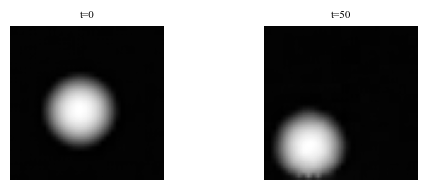

In [16]:
import matplotlib.pyplot as plt

ref_timesteps = 100
encoded_ref = torch.ones((ref_timesteps, latent_dim)).to(device)
encoded_ref[:50,0] = 0.4
encoded_ref[:50,1] = 0.4
encoded_ref[50:,0] = 0.1
encoded_ref[50:,1] = 0.1

# visualize the reference trajectory 
frames_ref = model.decoder(encoded_ref)
fig, axs = plt.subplots(1, 2, figsize=(6,2))   
axs[0].imshow(frames_ref[0,0].detach().cpu().numpy(), cmap='gray')
axs[0].set_title('t=0', fontproperties=times_font)
axs[0].axis('off')
axs[1].imshow(frames_ref[50,0].detach().cpu().numpy(), cmap='gray')
axs[1].set_title('t=50', fontproperties=times_font)
axs[1].axis('off')

We perform a closed-loop simulation to track the position of the ball using a proportional (P) controller:

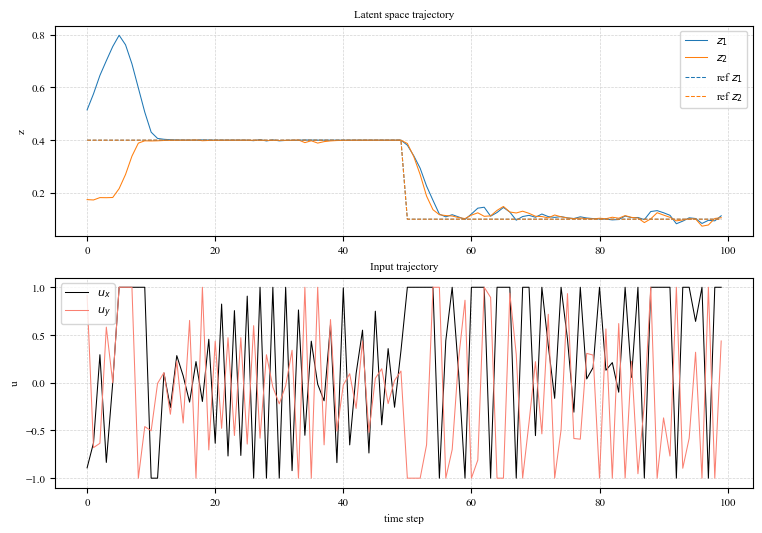

In [55]:
# history values
z_history = torch.zeros((ref_timesteps, latent_dim)).to(device)
u_history_P = torch.zeros((ref_timesteps, control_dim)).to(device)

# define the initial conditions
X0, U0, Y0 = processed_data['datasets']['test'][0]
Z0 = model.encoder(X0)
U0 = U0[:-1,:]
Z0.shape, U0.shape

# store the initial conditions
z_history[:lookback] = Z0
u_history_P[:lookback-1] = U0

# Proportional gain - P controller
n = latent_dim
Kp = 0.5 * torch.eye(n, device=device)

# loop over the timesteps
for t in range(lookback, ref_timesteps):
    # build the augmented state/input vector
    ksi = torch.cat((Z0.view(1,-1), U0.view(1,-1)), dim=1)

    # evaluate the model
    a_x = model.dynamics.drift_net(ksi).T                          
    B_x = model.dynamics.input_net(ksi).T.view(n, control_dim)   

    # 2) The linearized system will be controlled with a P controller
    e_k = encoded_ref[t].view(n,1) - Z0[-1].view(n,1)          
    v_k = Kp @ e_k                                      

    # 3) solve for u_k
    rank_B_x = torch.linalg.matrix_rank(B_x)
    if rank_B_x < n:
        print(f"Warning: B_x is not full rank at timestep {t}.")
        # Use pseudo-inverse to handle the case where B_x is not full rank
        B_x_inv = torch.linalg.pinv(B_x)
    else:
        # If B_x is full rank, use the inverse
        B_x_inv = torch.linalg.inv(B_x)
    # the ansatz is given as: z_k+1 = z_k + v_k
    u_k = B_x_inv @ ((Z0[-1].view(n,1) + v_k) - a_x)
    u_max= 1.0
    u_k = torch.clamp(u_k, min=-u_max, max=u_max)

    # store u
    u_history_P[t] = u_k.T

    # 4) propagate one step
    next_state = a_x + B_x @ u_k
    z_history[t] = next_state.T

    # 5) roll the histories forward
    Z0 = torch.cat((Z0[1:], next_state.T), dim=0)
    U0 = torch.cat((U0[1:], u_k.T), dim=0)

# plot the results 
fig, axs = plt.subplots(2,1, figsize=(9,6))
axs[0].plot(z_history[:,0].detach().cpu().numpy(), label=r"$z_1$", color='C0', linewidth=0.75)
axs[0].plot(z_history[:,1].detach().cpu().numpy(), label=r"$z_2$", color='C1', linewidth=0.75)
axs[0].plot(encoded_ref[:,0].detach().cpu().numpy(), label=r"ref $z_1$", linestyle='--', color='C0', linewidth=0.75)
axs[0].plot(encoded_ref[:,1].detach().cpu().numpy(), label=r"ref $z_2$", linestyle='--', color='C1', linewidth=0.75)
axs[1].plot(u_history_P[:,0].detach().cpu().numpy(),label=r"$u_x$", linewidth=0.75, color='black')
axs[1].plot(u_history_P[:,1].detach().cpu().numpy(),label=r"$u_y$", linewidth=0.75, color='salmon')
axs[0].set_title('Latent space trajectory', fontproperties=times_font)
axs[1].set_title('Input trajectory', fontproperties=times_font)
axs[0].legend(prop=times_font_leg)
axs[1].legend(prop=times_font_leg)
axs[0].grid(color='lightgray', linestyle='--', linewidth=0.5)
axs[1].grid(color='lightgray', linestyle='--', linewidth=0.5)
axs[0].set_ylabel('z', fontproperties=times_font)
axs[1].set_ylabel('u', fontproperties=times_font)
axs[1].set_xlabel('time step', fontproperties=times_font)
for ax in axs:
    for label in (ax.get_xticklabels() + ax.get_yticklabels()):
        label.set_fontproperties(times_font)
plt.show()
fig.savefig('./results_control_affine/ball_in_box_control_example1.pdf', bbox_inches='tight')

The high-dimensional states can be easily recovered using the decoder:

In [58]:
# decode the trajectory 
controlled_frames = model.decoder(z_history).cpu()

# visualize the controlled trajectory
from deepe2erom import animate_2Dsimulation
animate_2Dsimulation(controlled_frames, save_path='./results_control_affine/ball_in_box_control_example1.gif', cmap='gray')

Animation saved to: ./results_control_affine/ball_in_box_control_example1.gif


### Reference tracking of a circular trajectory

We now consider a more challenging scenario, where the goal is to track the movement of the ball along a circular path. To achieve this, we first generate a high-dimensional trajectory in which the ball follows a circular motion. This trajectory is then encoded into the latent space using the trained model, providing the reference latent trajectory for the controller to track.

In [4]:
from data_generation import generate_image, beta, gamma, k, r, time_step, steps, sigma_y

def simulate_circle(num_frames,
                    cx=0.6, cy=0.4,            # circle center (off-center by default)
                    rcirc=None,                # circle radius (if None computed safely)
                    noise_amplitude=0.1,
                    start_angle=0.0,
                    omega=2*np.pi/100.0):      # angular speed (radians per frame)
    """
    Produce frames where the ball center follows a circle:
      px(t) = cx + rcirc * cos(theta(t))
      py(t) = cy + rcirc * sin(theta(t))
    Ensures the center stays at least `r` away from domain borders.
    """
    # safety margin: make sure the center of the ball always stays in [r, 1-r]
    # compute a safe max radius if rcirc not provided
    max_r_x = min(cx - r, 1 - r - cx)
    max_r_y = min(cy - r, 1 - r - cy)
    safe_max = max(0.0, min(max_r_x, max_r_y))
    if rcirc is None:
        # choose rcirc somewhat smaller than the safe max to not be "too close"
        rcirc = max(0.0, 0.8 * safe_max)

    if rcirc <= 0:
        raise ValueError("rcirc computed as <= 0; pick a center (cx,cy) further from boundaries "
                         "or reduce ball radius `r`.")

    images = []
    theta = start_angle
    for t in range(num_frames):
        px = cx + rcirc * np.cos(theta)
        py = cy + rcirc * np.sin(theta)
        images.append(generate_image(px, py, noise_amplitude))
        theta += omega  # advance angle by omega radians per frame
    return images

# generate reference  frames
ref_timesteps = 200
frames = simulate_circle(num_frames=ref_timesteps, cx=0.6, cy=0.4, noise_amplitude=0.0,
                         start_angle=0.0, omega=4*np.pi/100.0)
frames = np.array(frames)

# Encode the frames and get the reference trajectory in latent space
frames_scaled = preprocessor.scale_trajectories(frames[np.newaxis,:,np.newaxis,:,:])
frames_scaled = torch.tensor(frames_scaled, dtype=torch.float32).to(device)
encoded_ref = model.encoder(frames_scaled[0])


We perform a closed-loop simulation to track the position of the ball using a proportional (P) controller:

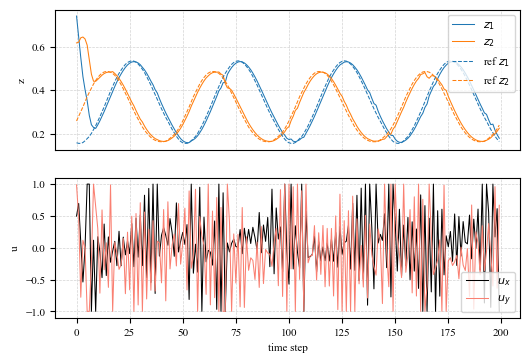

In [7]:
# history values
z_history = torch.zeros((ref_timesteps, latent_dim)).to(device)
u_history_P = torch.zeros((ref_timesteps, control_dim)).to(device)

# define the initial conditions
X0, U0, Y0 = processed_data['datasets']['test'][111]
Z0 = model.encoder(X0)
U0 = U0[:-1,:]
Z0.shape, U0.shape

# store the initial conditions
z_history[:lookback] = Z0
u_history_P[:lookback-1] = U0

# Proportional gain - P controller
n = latent_dim
Kp = 0.5 * torch.eye(n, device=device)

# loop over the timesteps
for t in range(lookback, ref_timesteps):
    # build the augmented state/input vector
    ksi = torch.cat((Z0.view(1,-1), U0.view(1,-1)), dim=1)

    # evaluate the model
    a_x = model.dynamics.drift_net(ksi).T                          
    B_x = model.dynamics.input_net(ksi).T.view(n, control_dim)   

    # 2) The linearized system will be controlled with a P controller
    e_k = encoded_ref[t].view(n,1) - Z0[-1].view(n,1)          
    v_k = Kp @ e_k                                      

    # 3) solve for u_k
    rank_B_x = torch.linalg.matrix_rank(B_x)
    if rank_B_x < n:
        print(f"Warning: B_x is not full rank at timestep {t}.")
        # Use pseudo-inverse to handle the case where B_x is not full rank
        B_x_inv = torch.linalg.pinv(B_x)
    else:
        # If B_x is full rank, use the inverse
        B_x_inv = torch.linalg.inv(B_x)
    # the ansatz is given as: z_k+1 = z_k + v_k
    u_k = B_x_inv @ ((Z0[-1].view(n,1) + v_k) - a_x)
    u_max= 1.0
    u_k = torch.clamp(u_k, min=-u_max, max=u_max)

    # store u
    u_history_P[t] = u_k.T

    # 4) propagate one step
    next_state = a_x + B_x @ u_k
    z_history[t] = next_state.T

    # 5) roll the histories forward
    Z0 = torch.cat((Z0[1:], next_state.T), dim=0)
    U0 = torch.cat((U0[1:], u_k.T), dim=0)

# plot the results 
fig, axs = plt.subplots(2,1, figsize=(6,4))
axs[0].plot(z_history[:,0].detach().cpu().numpy(), label=r"$z_1$", color='C0', linewidth=0.75)
axs[0].plot(z_history[:,1].detach().cpu().numpy(), label=r"$z_2$", color='C1', linewidth=0.75)
axs[0].plot(encoded_ref[:,0].detach().cpu().numpy(), label=r"ref $z_1$", linestyle='--', color='C0', linewidth=0.75)
axs[0].plot(encoded_ref[:,1].detach().cpu().numpy(), label=r"ref $z_2$", linestyle='--', color='C1', linewidth=0.75)
axs[0].set_xticklabels([])
axs[0].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
axs[1].plot(u_history_P[:,0].detach().cpu().numpy(),label=r"$u_x$", linewidth=0.75, color='black')
axs[1].plot(u_history_P[:,1].detach().cpu().numpy(),label=r"$u_y$", linewidth=0.75, color='salmon')
#axs[0].set_title('Latent space trajectory', fontproperties=times_font)
#axs[1].set_title('Input trajectory', fontproperties=times_font)
axs[0].legend(prop=times_font_leg)
axs[1].legend(prop=times_font_leg)
axs[0].grid(color='lightgray', linestyle='--', linewidth=0.5)
axs[1].grid(color='lightgray', linestyle='--', linewidth=0.5)
axs[0].set_ylabel('z', fontproperties=times_font)
axs[1].set_ylabel('u', fontproperties=times_font)
axs[1].set_xlabel('time step', fontproperties=times_font)
for ax in axs:
    for label in (ax.get_xticklabels() + ax.get_yticklabels()):
        label.set_fontproperties(times_font)
plt.show()
fig.savefig('./results_control_affine/ball_in_box_control_example2.pdf', bbox_inches='tight')